# Breast Cancer Dataset — Quick EDA

Binary classification dataset used to train the Rust `mlp` crate (`data/data.csv`).

- **Samples:** 569
- **Target:** `Diagnosis` — `M` (malignant) vs `B` (benign)
- **Features:** 30 numeric (10 base cell nuclei measurements × 3 summaries: `mean`, `se`, `extreme`)
- **Input model expects:** ID (dropped), Diagnosis encoded as 0/1, then 30 features

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

In [14]:
base_features = [
    "Radius", "Texture", "Perimeter", "Area", "Smoothness",
    "Compactness", "Concavity", "Concave Points", "Symmetry", "Fractal Dimension",
]
stats = ["mean", "se", "extreme"]

cols = ["ID", "Diagnosis"]
cols += [f"{f}_{s}" for f in base_features for s in stats]

df = pd.read_csv("../data/data.csv", header=None, names=cols)
df.head()

,ID,Diagnosis,Radius_mean,Radius_se,Radius_extreme,Texture_mean,Texture_se,Texture_extreme,Perimeter_mean,Perimeter_se,Perimeter_extreme,Area_mean,Area_se,Area_extreme,Smoothness_mean,Smoothness_se,Smoothness_extreme,Compactness_mean,Compactness_se,Compactness_extreme,Concavity_mean,Concavity_se,Concavity_extreme,Concave Points_mean,Concave Points_se,Concave Points_extreme,Symmetry_mean,Symmetry_se,Symmetry_extreme,Fractal Dimension_mean,Fractal Dimension_se,Fractal Dimension_extreme
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [15]:
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nMissing values: {df.isna().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Unique IDs: {df['ID'].nunique()} (rows {len(df)})")

Shape: 569 rows x 32 columns

Missing values: 0
Duplicate rows: 0
Unique IDs: 569 (rows 569)


## 1. Target distribution

Diagnosis
B    357
M    212
Name: count, dtype: int64

Class imbalance: 37.3% malignant, 62.7% benign


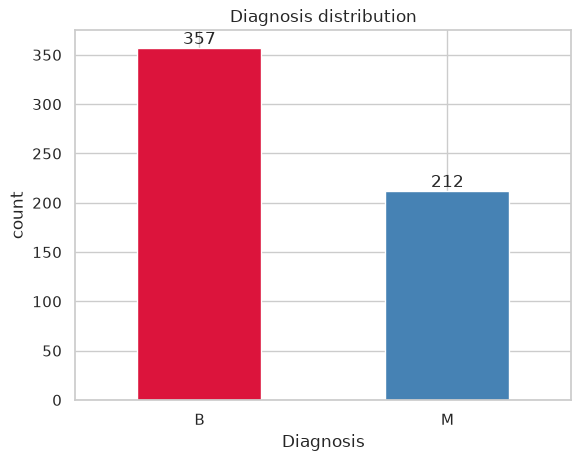

In [16]:
counts = df["Diagnosis"].value_counts()
print(counts)
print(f"\nClass imbalance: {counts['M'] / len(df):.1%} malignant, {counts['B'] / len(df):.1%} benign")

ax = counts.plot.bar(color=["crimson", "steelblue"], rot=0)
ax.set_title("Diagnosis distribution")
ax.set_ylabel("count")
for i, v in enumerate(counts.values):
    ax.text(i, v, str(v), ha="center", va="bottom")
plt.show()

## 2. Summary statistics

In [17]:
df.drop(columns=["ID"]).describe().T

,count,mean,std,min,25%,50%,75%,max
Radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
Radius_se,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
Radius_extreme,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
Texture_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
Texture_se,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
Texture_extreme,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
Perimeter_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
Perimeter_se,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
Perimeter_extreme,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
Area_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


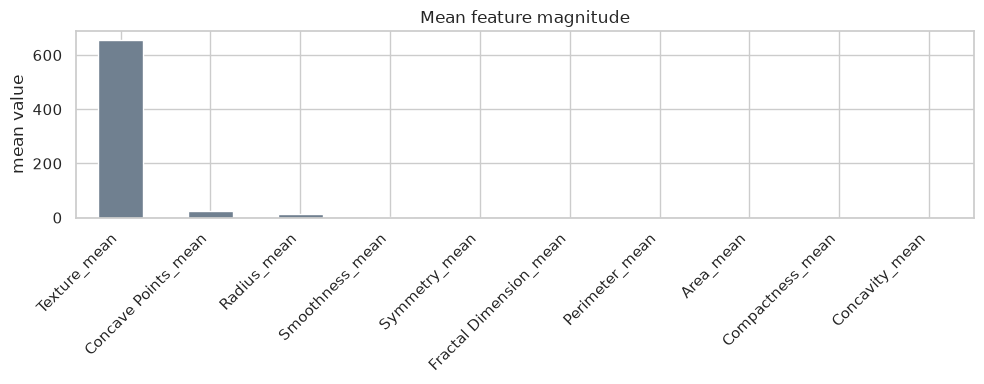

In [18]:
mean_cols = [c for c in cols if c.endswith("_mean")]
feature_means = df[mean_cols].mean().sort_values(ascending=False)

feature_means.plot.bar(figsize=(10, 4), color="slategray")
plt.title("Mean feature magnitude")
plt.ylabel("mean value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 3. Feature distributions by diagnosis

Histograms of the 10 `mean` features, colored by class. Overlap = harder to separate; separation = useful signal.

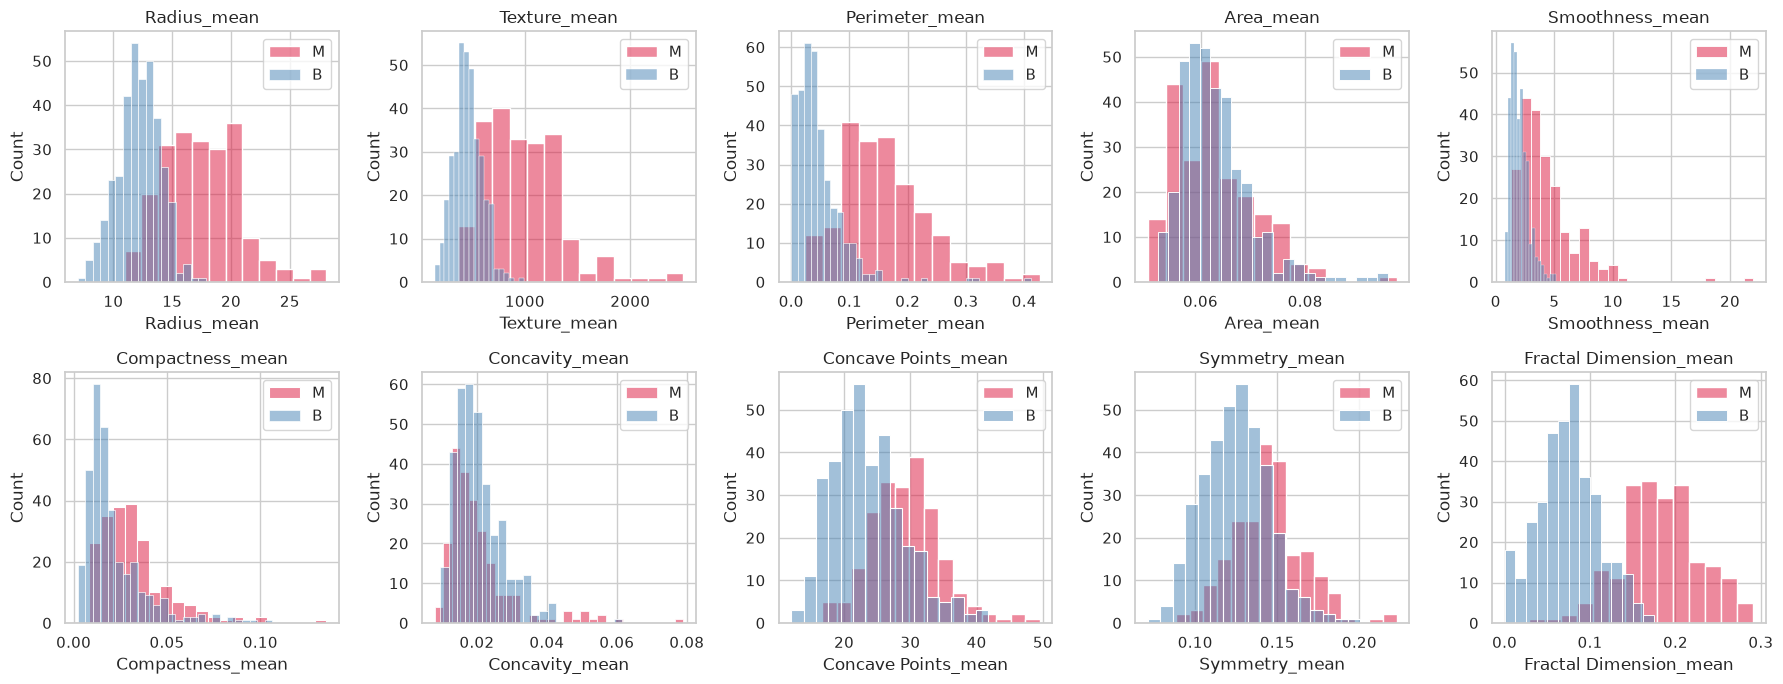

In [19]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, col in zip(axes.ravel(), mean_cols):
    for label, color in [("M", "crimson"), ("B", "steelblue")]:
        sns.histplot(df.loc[df["Diagnosis"] == label, col], ax=ax, color=color, alpha=0.5, label=label, kde=False)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

## 4. Correlation structure

`extreme` features are the highest-correlated with the target — and many features are strongly correlated with each other (multicollinearity).

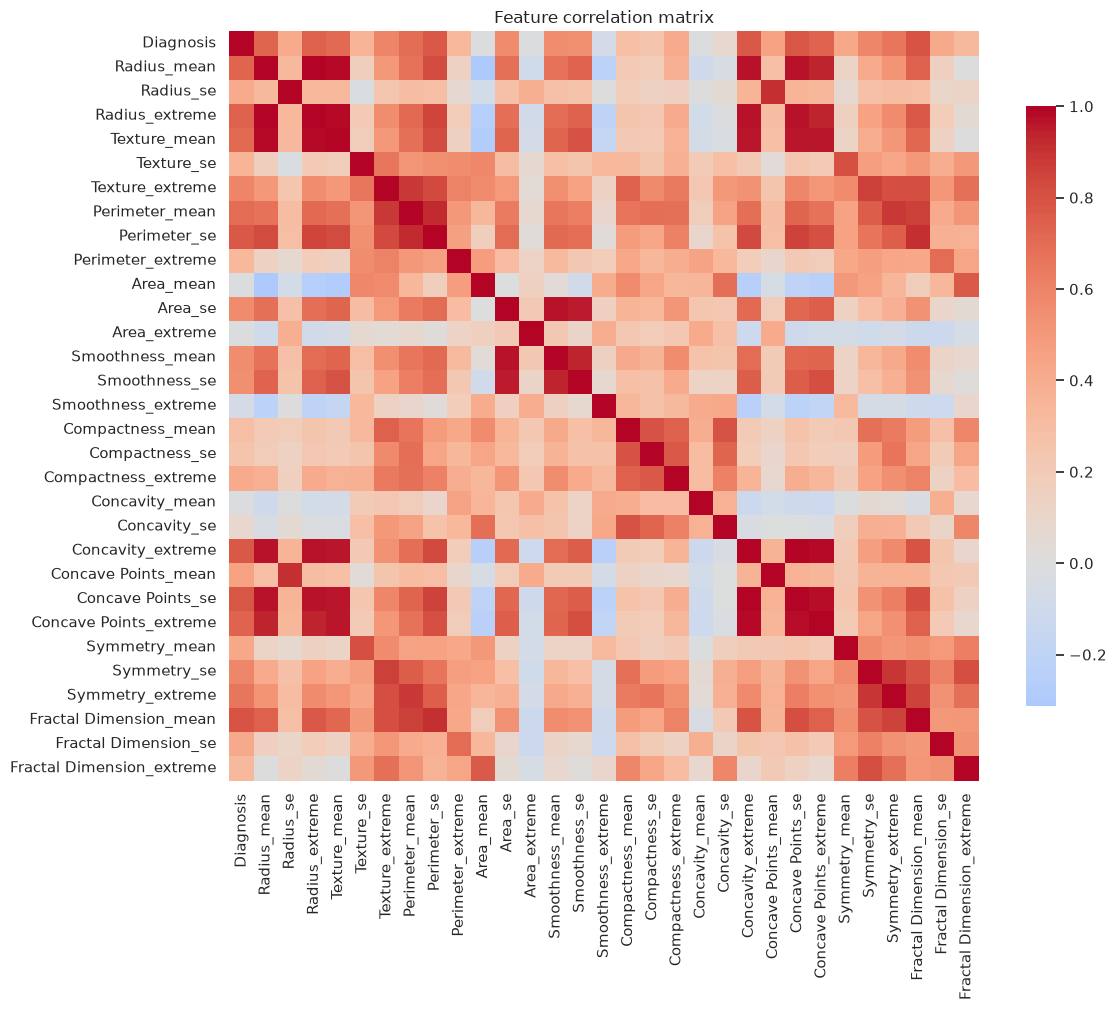

In [20]:
df_enc = df.copy()
df_enc["Diagnosis"] = (df_enc["Diagnosis"] == "M").astype(int)

corr = df_enc.drop(columns=["ID"]).corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": 0.8})
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()

In [21]:
corr_target = corr["Diagnosis"].drop("Diagnosis").sort_values(ascending=False)
print("Top 10 features by |correlation| with Diagnosis:")
print(corr_target.abs().sort_values(ascending=False).head(10).to_string())
print("\nFeatures correlated >0.9 with each other (count):",
      int(((corr.drop(columns=["Diagnosis"]).abs() > 0.9).sum().sum() - 30) / 2))

Top 10 features by |correlation| with Diagnosis:
Fractal Dimension_mean    0.793566
Concave Points_se         0.782914
Perimeter_se              0.776614
Concavity_extreme         0.776454
Radius_extreme            0.742636
Concave Points_extreme    0.733825
Radius_mean               0.730029
Texture_mean              0.708984
Perimeter_mean            0.696360
Symmetry_extreme          0.659610

Features correlated >0.9 with each other (count): 21


## 5. Scale check

Features live on very different scales (e.g. Area ~1000 vs Smoothness ~0.01). The Rust pipeline uses a `StandardScaler` fit on the **training** split — this is why.

In [22]:
feature_cols = [c for c in cols if c not in ("ID", "Diagnosis")]
print(df[feature_cols].std().describe())
print("\nStd range:", df[feature_cols].std().min().round(4), "->", df[feature_cols].std().max().round(1))

count     30.000000
mean      34.904719
std      119.675765
min        0.002646
25%        0.019254
50%        0.072726
75%        4.106789
max      569.356993
dtype: float64

Std range: 0.0026 -> 569.4


## Key takeaways

- 569 samples, no missing values, no duplicates, no train/test leakage in the raw file.
- Slightly imbalanced (~37% malignant) — stratify when splitting (the Rust split does).
- `extreme` features separate the classes best; `Area_extreme`, `Perimeter_extreme`, `Concave Points_extreme` dominate.
- Heavy multicollinearity within `mean`/`se`/`extreme` triplets (Area–Perimeter–Radius correlate >0.9) — fine for an MLP, bad for linear models.
- Large scale differences → z-score standardization (already done via `StandardScaler` in the pipeline).